# 🏠 Airbnb NYC — Data Analysis & Price Prediction
**Algonive Internship | Data Analytics | Task 2**

---
### Objective
Analyze Airbnb NYC listings to understand key pricing factors and build a machine learning model to predict listing prices based on features like location, room type, amenities, and more.

### Pipeline
1. Dataset Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. ML Model — Price Prediction
6. Dashboard & Visualization Summary

---
> **Dataset Source:** [Kaggle — Airbnb NYC Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

## 📦 Step 0: Install & Import Libraries

In [5]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly folium

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optional: XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print('XGBoost not installed. Skipping XGBoost model.')

# Plot settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 1: Load Dataset

> Download `AB_NYC_2019.csv` from [Kaggle](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) and place it in the same folder as this notebook.

In [6]:
# Load the dataset
df = pd.read_csv('AB_NYC_2019.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Dataset Shape: (48895, 16)
Rows: 48,895 | Columns: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [8]:
# Statistical summary
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
id,48895.000000,19017143.236180,10983108.385610,2539.000000,9471945.000000,19677284.000000,29152178.500000,36487245.000000
host_id,48895.000000,67620010.646610,78610967.032667,2438.000000,7822033.000000,30793816.000000,107434423.000000,274321313.000000
latitude,48895.000000,40.728949,0.054530,40.499790,40.690100,40.723070,40.763115,40.913060
longitude,48895.000000,-73.952170,0.046157,-74.244420,-73.983070,-73.955680,-73.936275,-73.712990
price,48895.000000,152.720687,240.154170,0.000000,69.000000,106.000000,175.000000,10000.000000
minimum_nights,48895.000000,7.029962,20.510550,1.000000,1.000000,3.000000,5.000000,1250.000000
number_of_reviews,48895.000000,23.274466,44.550582,0.000000,1.000000,5.000000,24.000000,629.000000
reviews_per_month,38843.000000,1.373221,1.680442,0.010000,0.190000,0.720000,2.020000,58.500000
calculated_host_listings_count,48895.000000,7.143982,32.952519,1.000000,1.000000,1.000000,2.000000,327.000000
availability_365,48895.000000,112.781327,131.622289,0.000000,0.000000,45.000000,227.000000,365.000000


---
## 🧹 Step 2: Data Cleaning & Preprocessing

Columns with Missing Values:
                   Missing Count  Missing %
reviews_per_month          10052      20.56
last_review                10052      20.56
host_name                     21       0.04
name                          16       0.03


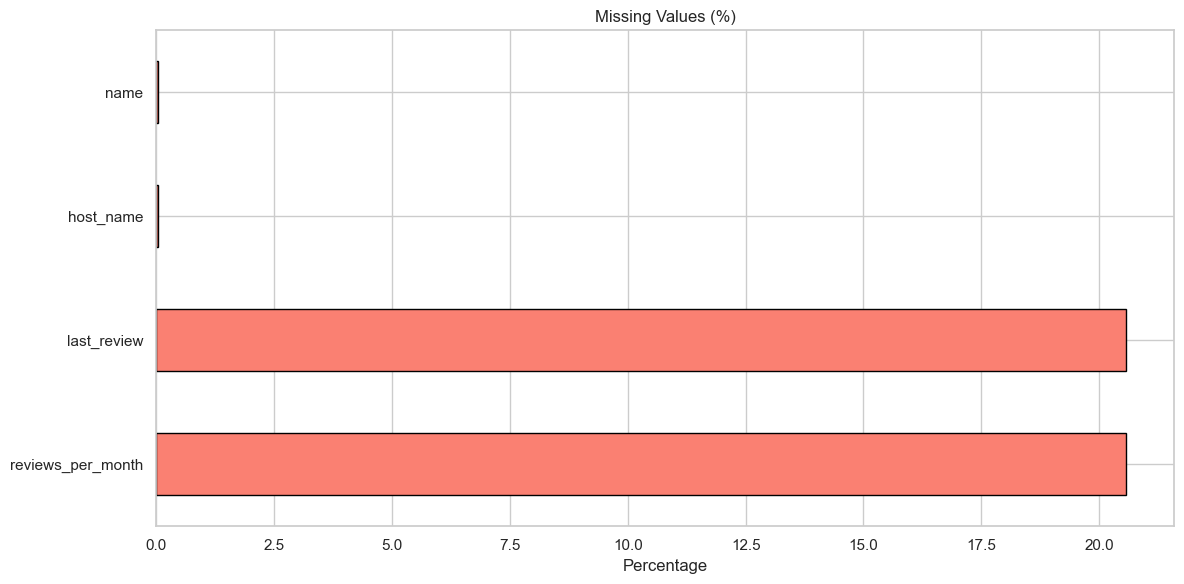

In [9]:
# ── 2.1 Check Missing Values ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with Missing Values:')
print(missing_df)

# Visualise
if not missing_df.empty:
    missing_df['Missing %'].plot(kind='barh', color='salmon', edgecolor='black')
    plt.title('Missing Values (%)')
    plt.xlabel('Percentage')
    plt.tight_layout()
    plt.show()

In [10]:
# ── 2.2 Handle Missing Values ──
# Fill text fields
df['name'].fillna('Unknown', inplace=True)
df['host_name'].fillna('Unknown', inplace=True)

# Reviews per month — fill with 0 (no reviews)
df['reviews_per_month'].fillna(0, inplace=True)

# Last review — fill with placeholder
df['last_review'].fillna('2000-01-01', inplace=True)

print(f'Missing values after cleaning: {df.isnull().sum().sum()}')

Missing values after cleaning: 0


In [11]:
# ── 2.3 Remove Outliers in Price ──
print(f'Rows before outlier removal: {len(df):,}')

# Remove price = 0 (invalid listings)
df = df[df['price'] > 0]

# Remove extreme outliers using IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()
print(f'Rows after outlier removal : {len(df_clean):,}')
print(f'Price range kept           : ${lower_bound:.0f} – ${upper_bound:.0f}')

Rows before outlier removal: 48,895
Rows after outlier removal : 45,912
Price range kept           : $-90 – $334


In [12]:
# ── 2.4 Drop Unnecessary Columns ──
drop_cols = ['id', 'name', 'host_name', 'last_review']
df_clean.drop(columns=drop_cols, inplace=True)
print(f'Remaining columns: {list(df_clean.columns)}')

Remaining columns: ['host_id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


---
## 📊 Step 3: Exploratory Data Analysis (EDA)

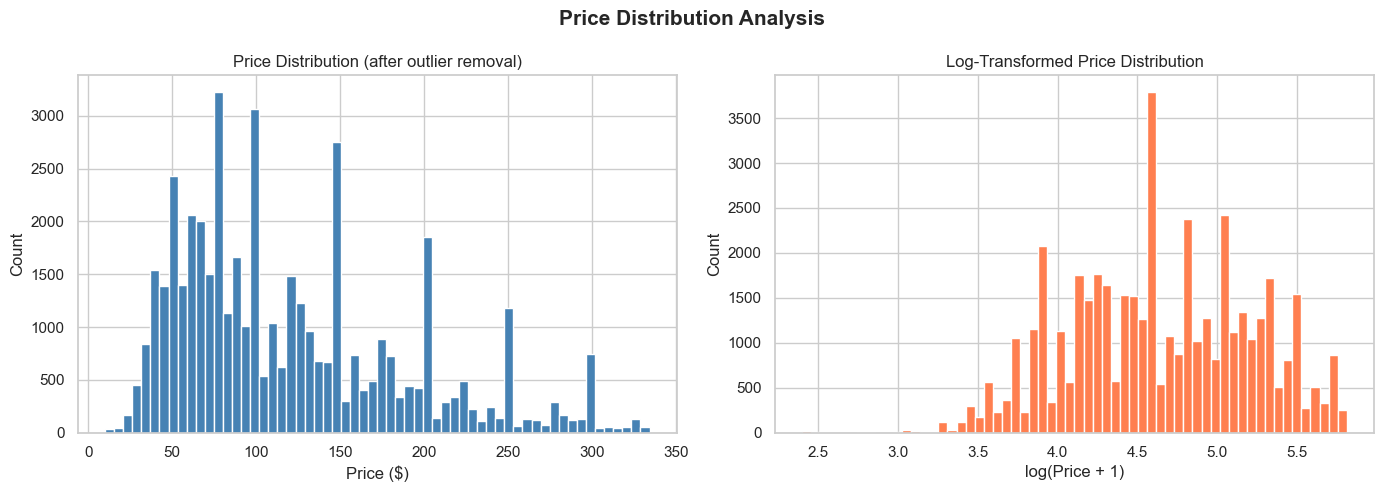

In [13]:
# ── 3.1 Price Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (after outlier removal)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_clean['price']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Price Distribution Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

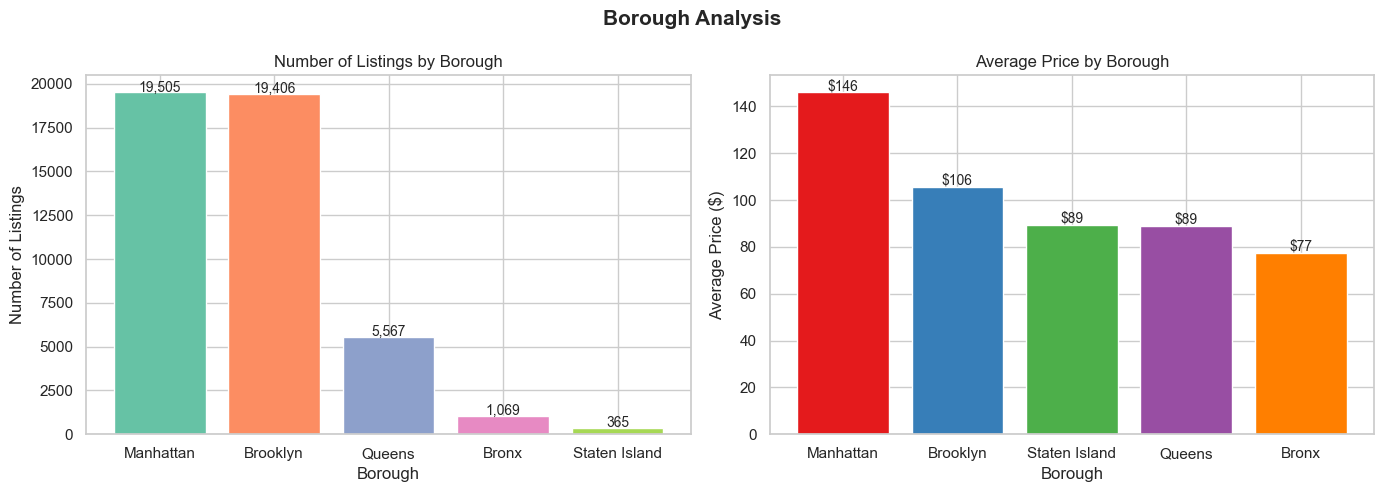

In [14]:
# ── 3.2 Listings by Neighbourhood Group ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neighbourhood_counts = df_clean['neighbourhood_group'].value_counts()
axes[0].bar(neighbourhood_counts.index, neighbourhood_counts.values,
            color=sns.color_palette('Set2', len(neighbourhood_counts)))
axes[0].set_title('Number of Listings by Borough')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Number of Listings')
for i, v in enumerate(neighbourhood_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Average price by borough
avg_price = df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
axes[1].bar(avg_price.index, avg_price.values,
            color=sns.color_palette('Set1', len(avg_price)))
axes[1].set_title('Average Price by Borough')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Average Price ($)')
for i, v in enumerate(avg_price.values):
    axes[1].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=10)

plt.suptitle('Borough Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

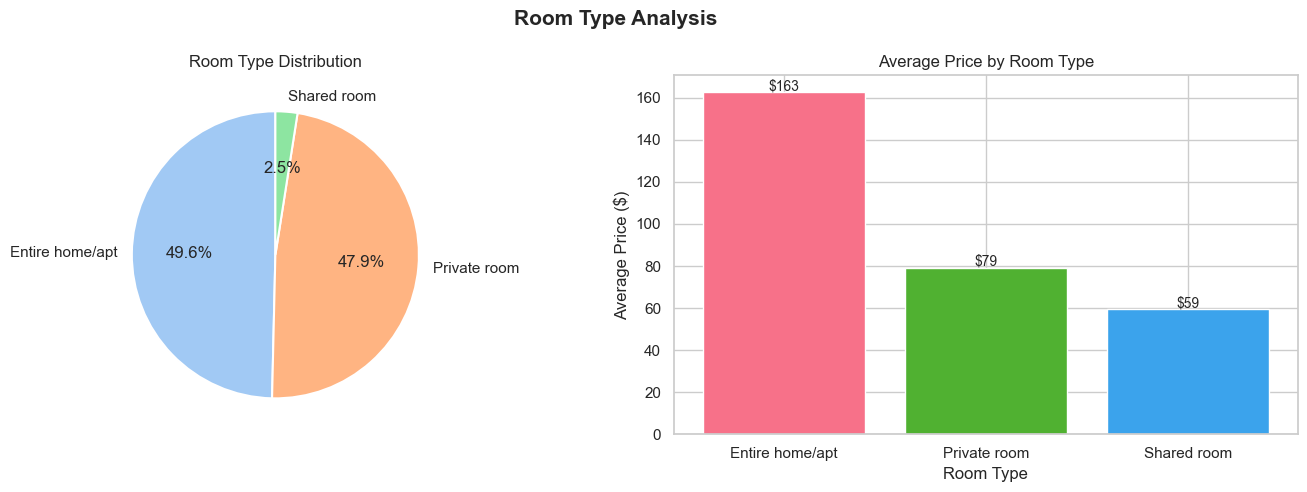

In [15]:
# ── 3.3 Room Type Analysis ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_counts = df_clean['room_type'].value_counts()
axes[0].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel'), startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Room Type Distribution')

room_price = df_clean.groupby('room_type')['price'].mean().sort_values(ascending=False)
axes[1].bar(room_price.index, room_price.values,
            color=sns.color_palette('husl', len(room_price)))
axes[1].set_title('Average Price by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Average Price ($)')
for i, v in enumerate(room_price.values):
    axes[1].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=10)

plt.suptitle('Room Type Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

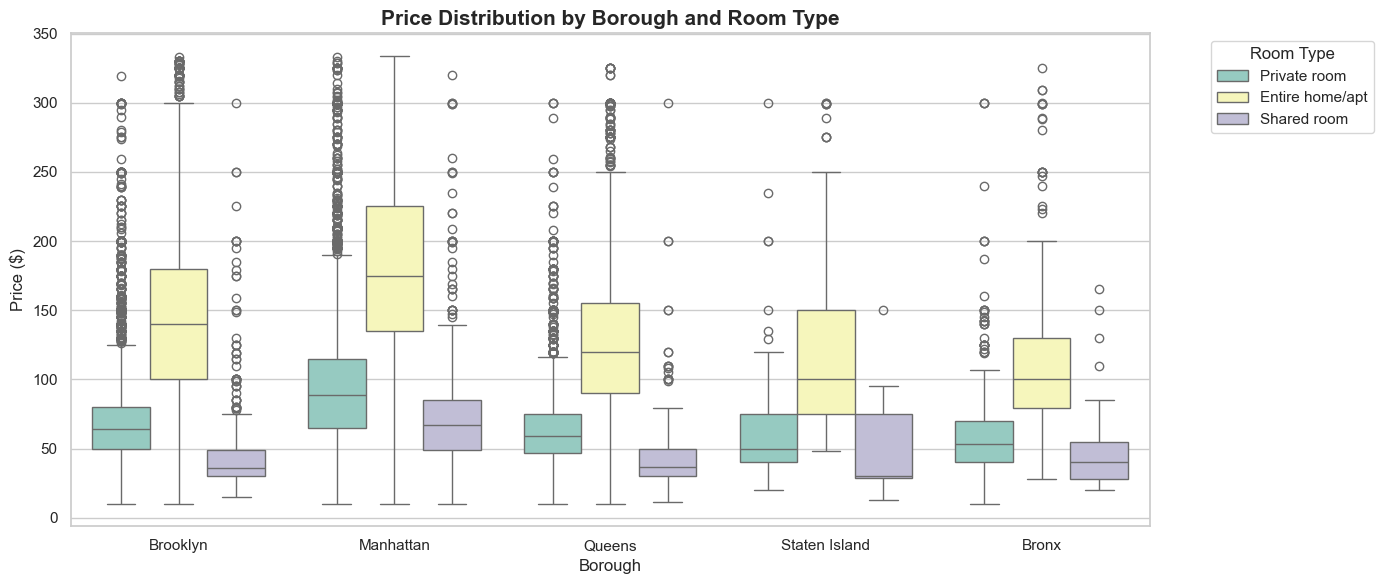

In [16]:
# ── 3.4 Price by Borough + Room Type (Boxplot) ──
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean, x='neighbourhood_group', y='price', hue='room_type',
            palette='Set3')
plt.title('Price Distribution by Borough and Room Type', fontsize=15, fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

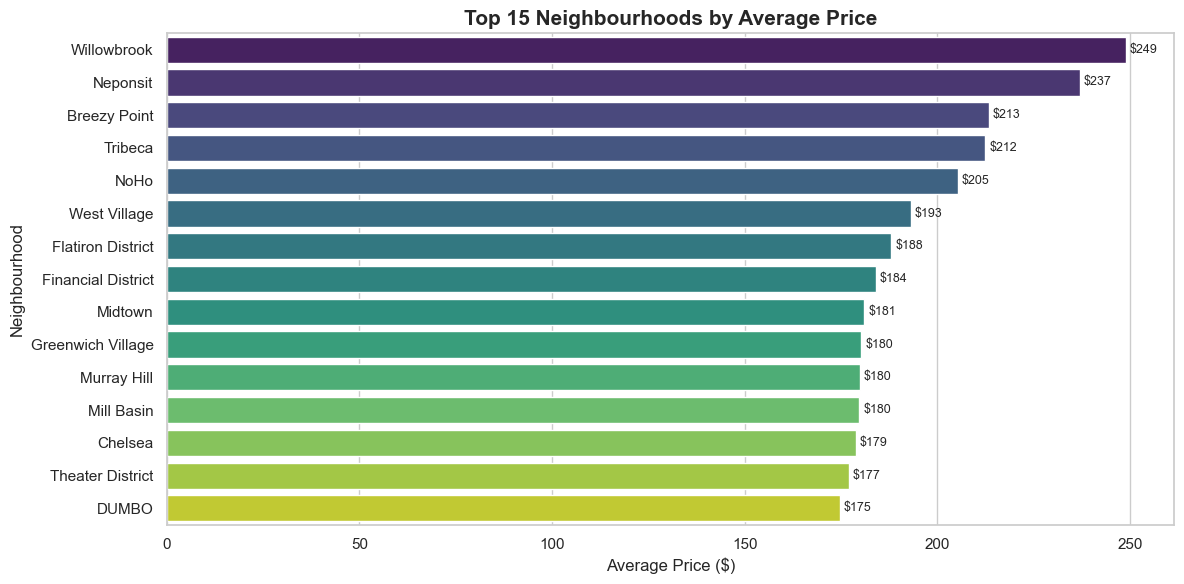

In [17]:
# ── 3.5 Top 15 Neighbourhoods by Average Price ──
top_neighbourhoods = (df_clean.groupby('neighbourhood')['price']
                      .mean().sort_values(ascending=False).head(15))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index,
            palette='viridis')
plt.title('Top 15 Neighbourhoods by Average Price', fontsize=15, fontweight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighbourhood')
for i, v in enumerate(top_neighbourhoods.values):
    plt.text(v + 1, i, f'${v:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

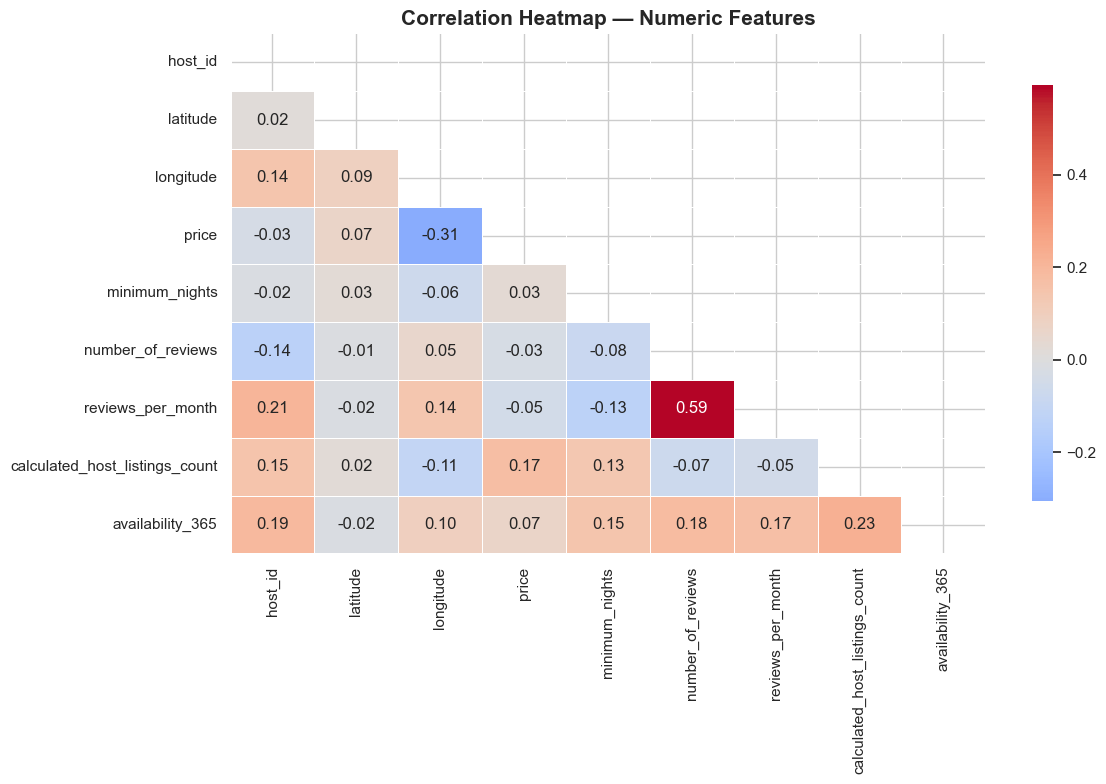

In [18]:
# ── 3.6 Correlation Heatmap ──
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

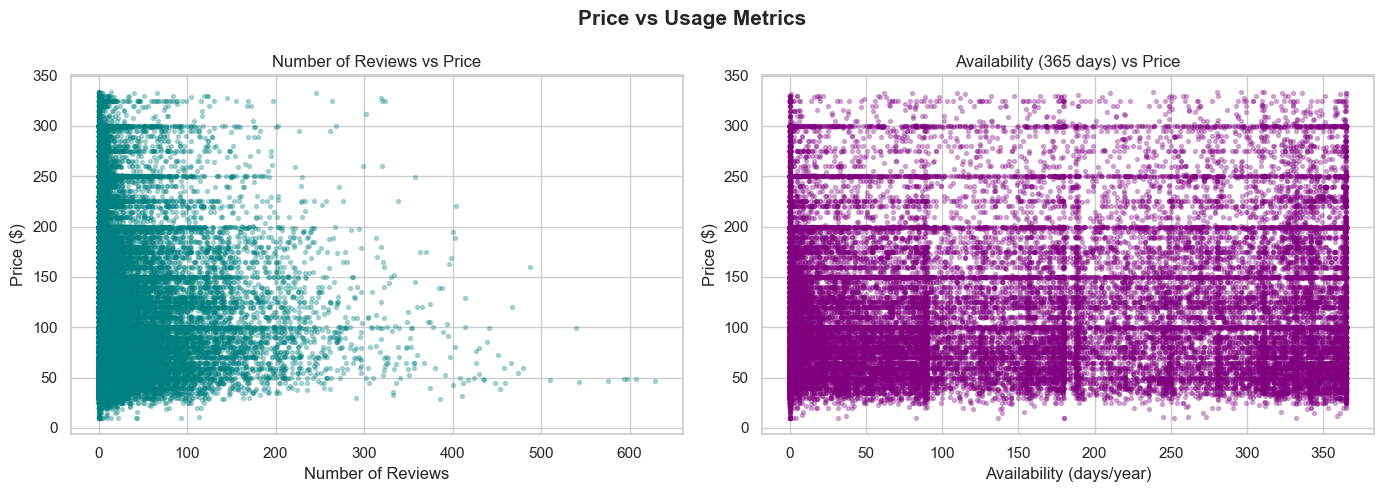

In [19]:
# ── 3.7 Reviews vs Price (Scatter) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['number_of_reviews'], df_clean['price'],
                alpha=0.3, color='teal', s=8)
axes[0].set_title('Number of Reviews vs Price')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Price ($)')

axes[1].scatter(df_clean['availability_365'], df_clean['price'],
                alpha=0.3, color='purple', s=8)
axes[1].set_title('Availability (365 days) vs Price')
axes[1].set_xlabel('Availability (days/year)')
axes[1].set_ylabel('Price ($)')

plt.suptitle('Price vs Usage Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── 3.8 Geographic Distribution (Plotly Interactive Map) ──
sample = df_clean.sample(5000, random_state=42)  # sample for performance

fig = px.scatter_mapbox(
    sample,
    lat='latitude', lon='longitude',
    color='neighbourhood_group',
    size='price',
    hover_data=['price', 'room_type', 'neighbourhood'],
    color_discrete_sequence=px.colors.qualitative.Bold,
    zoom=10, height=550,
    title='NYC Airbnb Listings — Geographic Distribution'
)
fig.update_layout(mapbox_style='open-street-map', margin={'r':0,'t':50,'l':0,'b':0})
fig.show()

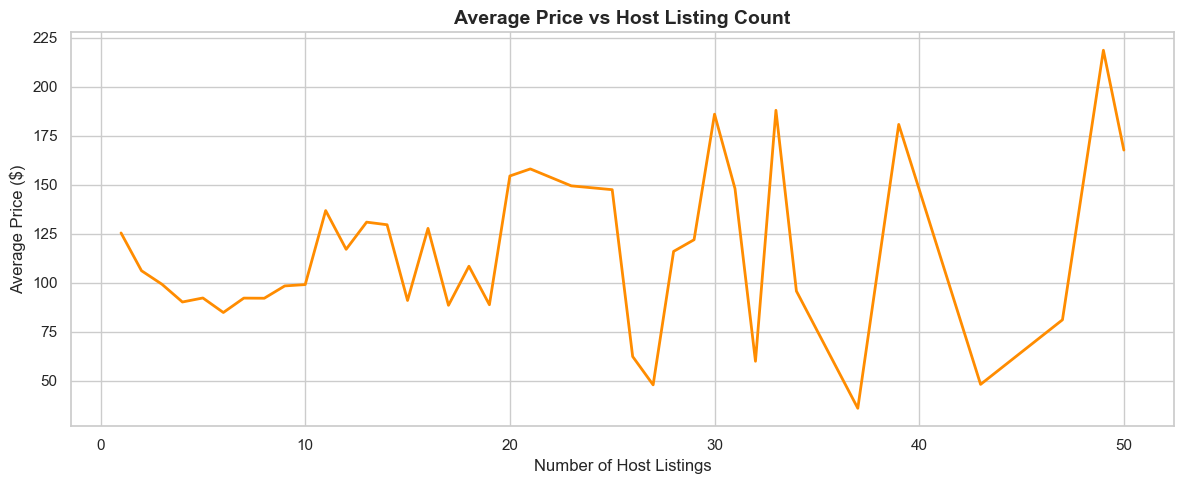

In [21]:
# ── 3.9 Host Listing Count vs Price ──
host_stats = (df_clean.groupby('calculated_host_listings_count')
              ['price'].mean().reset_index()
              .query('calculated_host_listings_count <= 50'))

plt.figure(figsize=(12, 5))
sns.lineplot(data=host_stats, x='calculated_host_listings_count', y='price',
             color='darkorange', linewidth=2)
plt.title('Average Price vs Host Listing Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Host Listings')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

---
## ⚙️ Step 4: Feature Engineering

In [22]:
df_model = df_clean.copy()

# ── 4.1 Encode Categorical Features ──
le = LabelEncoder()
df_model['neighbourhood_group_enc'] = le.fit_transform(df_model['neighbourhood_group'])
df_model['neighbourhood_enc']       = le.fit_transform(df_model['neighbourhood'])
df_model['room_type_enc']           = le.fit_transform(df_model['room_type'])

# ── 4.2 New Features ──
# reviews_per_month already present; add a binary 'has_reviews' flag
df_model['has_reviews'] = (df_model['number_of_reviews'] > 0).astype(int)

# Availability ratio (0–1)
df_model['availability_ratio'] = df_model['availability_365'] / 365

# Is highly available (>180 days/yr)
df_model['high_availability'] = (df_model['availability_365'] > 180).astype(int)

# Is popular host (listed >5 times)
df_model['popular_host'] = (df_model['calculated_host_listings_count'] > 5).astype(int)

# Log-transform target
df_model['log_price'] = np.log1p(df_model['price'])

print('✅ Feature engineering complete.')
print(f'Total features in model df: {df_model.shape[1]}')
df_model.head(3)

✅ Feature engineering complete.
Total features in model df: 20


,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_enc,neighbourhood_enc,room_type_enc,has_reviews,availability_ratio,high_availability,popular_host,log_price
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,107,1,1,1.000000,1,1,5.010635
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2,126,0,1,0.972603,1,0,5.420535
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,2,93,1,0,1.000000,1,0,5.017280


In [23]:
# ── 4.3 Select Features for Model ──
FEATURE_COLS = [
    'neighbourhood_group_enc',
    'neighbourhood_enc',
    'latitude',
    'longitude',
    'room_type_enc',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'has_reviews',
    'availability_ratio',
    'high_availability',
    'popular_host'
]

TARGET = 'log_price'

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

print(f'Features: {len(FEATURE_COLS)} | Samples: {len(X):,}')

Features: 14 | Samples: 45,912


---
## 🤖 Step 5: Machine Learning — Price Prediction

In [24]:
# ── 5.1 Train-Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 36,729 | Test: 9,183


In [25]:
# ── 5.2 Define & Train Multiple Models ──
models = {
    'Linear Regression'         : LinearRegression(),
    'Ridge Regression'          : Ridge(alpha=1.0),
    'Lasso Regression'          : Lasso(alpha=0.01),
    'Decision Tree'             : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'             : RandomForestRegressor(n_estimators=150, max_depth=15,
                                                        random_state=42, n_jobs=-1),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=150, max_depth=5,
                                                             learning_rate=0.1, random_state=42),
}

if xgb_available:
    models['XGBoost'] = XGBRegressor(n_estimators=200, max_depth=6,
                                     learning_rate=0.05, random_state=42,
                                     verbosity=0)

results = []

for name, model in models.items():
    # Use scaled data for linear models, raw for tree-based
    is_linear = name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
    Xtr = X_train_sc if is_linear else X_train
    Xte = X_test_sc  if is_linear else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    # Convert log predictions back to price
    y_pred_price = np.expm1(y_pred)
    y_test_price = np.expm1(y_test)

    mae  = mean_absolute_error(y_test_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
    r2   = r2_score(y_test, y_pred)        # R² on log scale

    results.append({'Model': name, 'MAE ($)': round(mae,2),
                    'RMSE ($)': round(rmse,2), 'R² (log)': round(r2,4)})
    print(f'{name:28s} | MAE: ${mae:6.2f} | RMSE: ${rmse:7.2f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R² (log)', ascending=False)
print('\n✅ All models trained!')

Linear Regression            | MAE: $ 35.54 | RMSE: $  50.26 | R²: 0.5124
Ridge Regression             | MAE: $ 35.54 | RMSE: $  50.26 | R²: 0.5124
Lasso Regression             | MAE: $ 35.92 | RMSE: $  50.67 | R²: 0.5060
Decision Tree                | MAE: $ 32.31 | RMSE: $  46.45 | R²: 0.5895
Random Forest                | MAE: $ 30.25 | RMSE: $  43.61 | R²: 0.6433
Gradient Boosting            | MAE: $ 30.62 | RMSE: $  43.98 | R²: 0.6400
XGBoost                      | MAE: $ 30.57 | RMSE: $  43.96 | R²: 0.6413

✅ All models trained!


In [26]:
# ── 5.3 Model Comparison Table ──
results_df.style.background_gradient(subset=['R² (log)'], cmap='Greens') \
               .background_gradient(subset=['MAE ($)', 'RMSE ($)'], cmap='Reds_r') \
               .set_caption('Model Performance Comparison')

,Model,MAE ($),RMSE ($),R² (log)
4,Random Forest,30.250000,43.610000,0.643300
6,XGBoost,30.570000,43.960000,0.641300
5,Gradient Boosting,30.620000,43.980000,0.640000
3,Decision Tree,32.310000,46.450000,0.589500
0,Linear Regression,35.540000,50.260000,0.512400
1,Ridge Regression,35.540000,50.260000,0.512400
2,Lasso Regression,35.920000,50.670000,0.506000


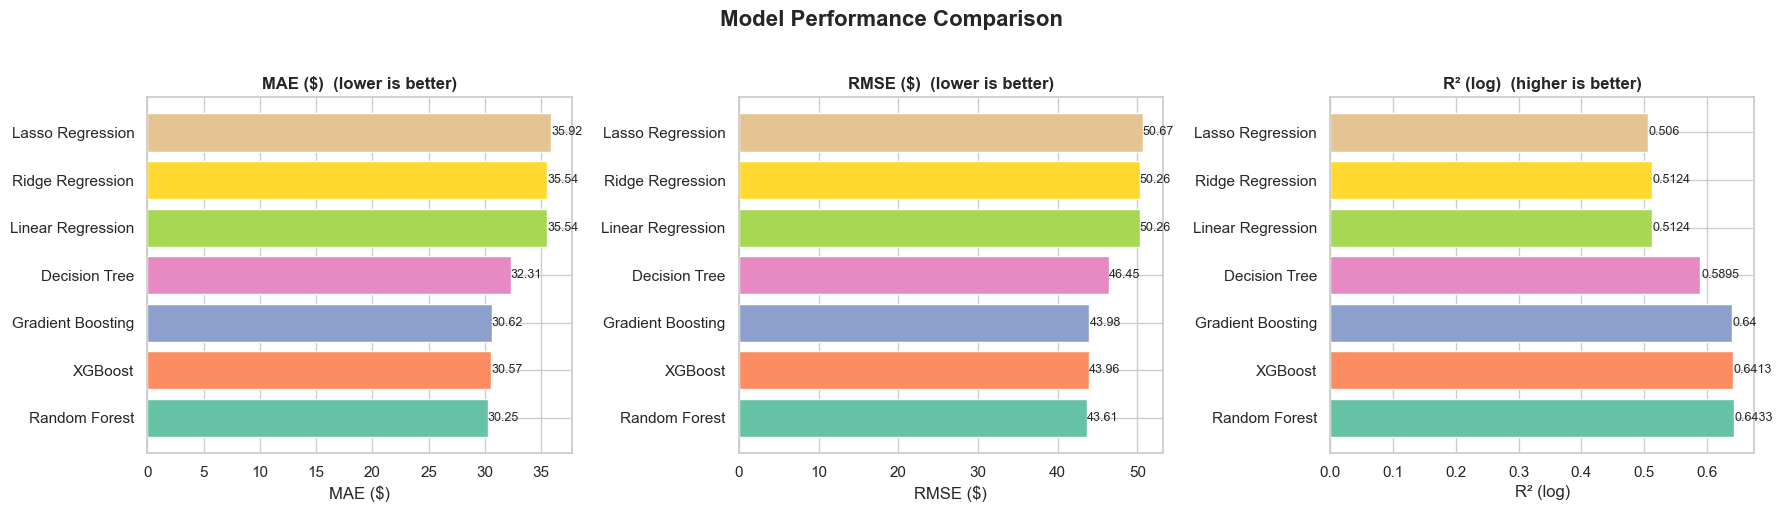

In [27]:
# ── 5.4 Model Comparison Bar Charts ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('Set2', len(results_df))

for ax, metric, better in zip(axes, ['MAE ($)', 'RMSE ($)', 'R² (log)'],
                               ['lower', 'lower', 'higher']):
    sorted_df = results_df.sort_values(metric, ascending=(better == 'lower'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    ax.set_title(f'{metric}  ({better} is better)', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Best Model: Random Forest


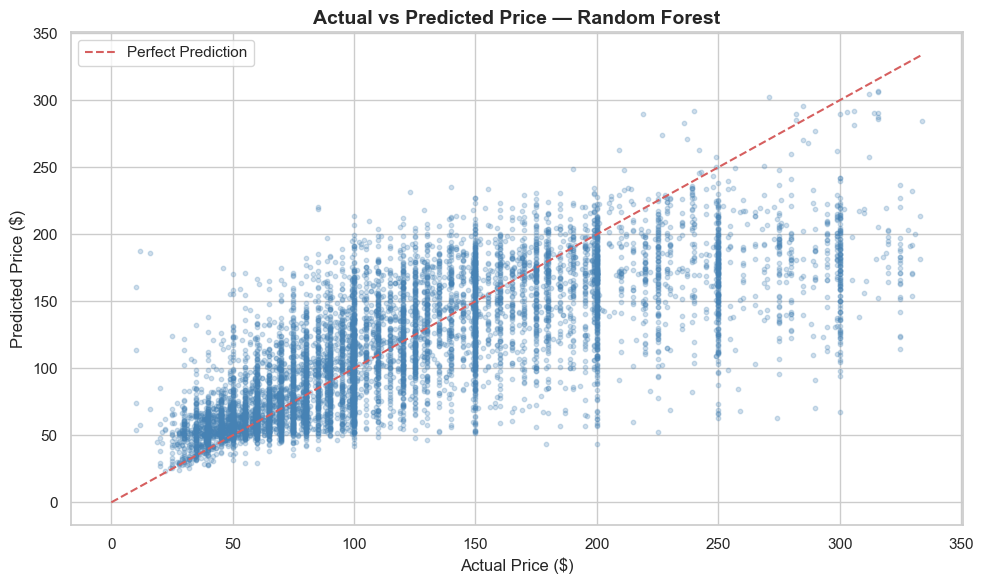

In [28]:
# ── 5.5 Best Model: Actual vs Predicted ──
best_model_name = results_df.iloc[0]['Model']
print(f'Best Model: {best_model_name}')

best_model = models[best_model_name]
is_linear  = best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
Xte        = X_test_sc if is_linear else X_test

y_pred_best  = best_model.predict(Xte)
y_pred_price = np.expm1(y_pred_best)
y_test_price = np.expm1(y_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_price, y_pred_price, alpha=0.25, color='steelblue', s=10)
max_val = max(y_test_price.max(), y_pred_price.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Price — {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

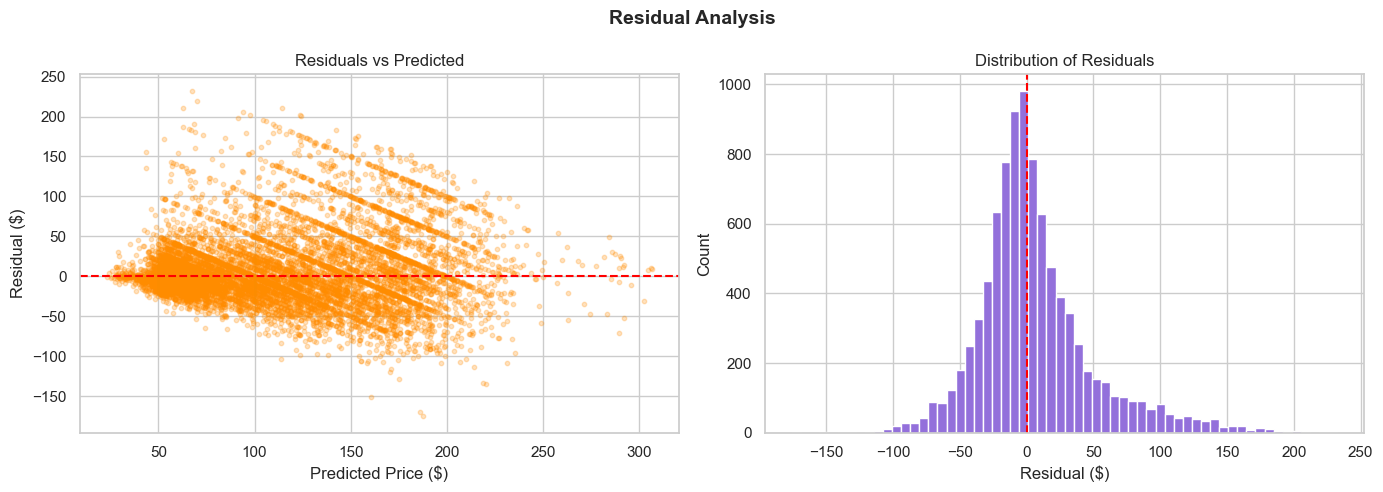

In [29]:
# ── 5.6 Residual Analysis ──
residuals = y_test_price.values - y_pred_price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_price, residuals, alpha=0.25, color='darkorange', s=10)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual ($)')

axes[1].hist(residuals, bins=60, color='mediumpurple', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

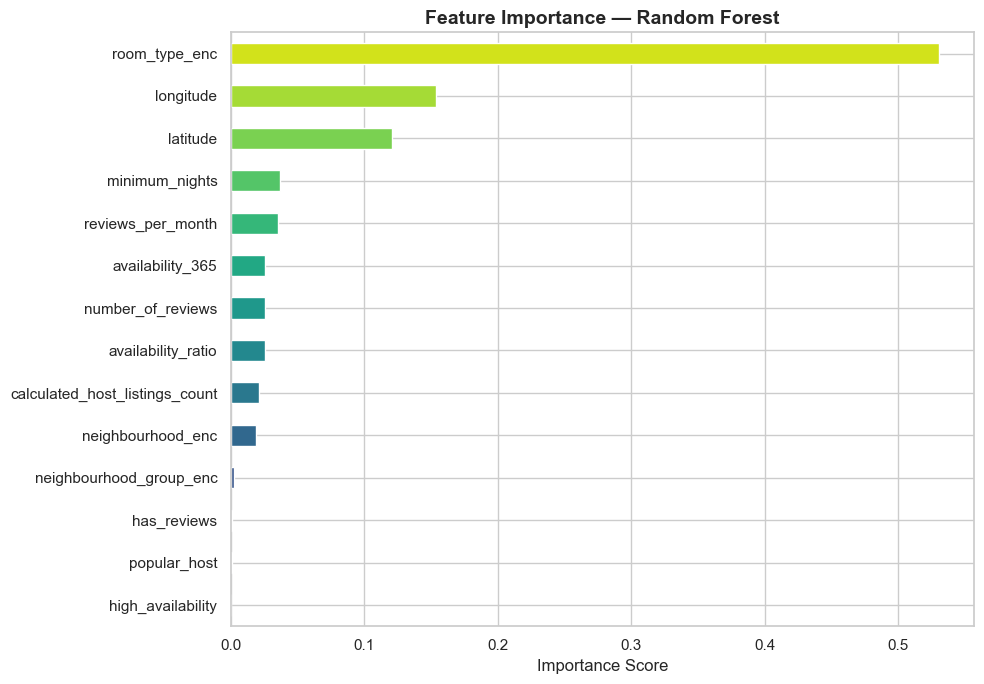

In [30]:
# ── 5.7 Feature Importance (Tree-Based Models) ──
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']
fi_model_name = next((m for m in tree_models if m in models), None)

if fi_model_name:
    fi_model = models[fi_model_name]
    importance = pd.Series(fi_model.feature_importances_, index=FEATURE_COLS)
    importance = importance.sort_values(ascending=True)

    plt.figure(figsize=(10, 7))
    importance.plot(kind='barh', color=sns.color_palette('viridis', len(importance)))
    plt.title(f'Feature Importance — {fi_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print('No tree-based model available for feature importance.')

---
## 📈 Step 6: Dashboard Summary — Key Insights

In [31]:
# ── 6.1 Comprehensive Dashboard ──
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Listings by Borough',
        'Avg Price by Borough',
        'Room Type Share',
        'Avg Price by Room Type',
        'Price Distribution',
        'Model R² Comparison'
    ],
    specs=[[{'type':'bar'}, {'type':'bar'}, {'type':'pie'}],
           [{'type':'bar'}, {'type':'histogram'}, {'type':'bar'}]]
)

pal = px.colors.qualitative.Bold

# Row 1 Col 1
ng = df_clean['neighbourhood_group'].value_counts()
fig.add_trace(go.Bar(x=ng.index.tolist(), y=ng.values.tolist(),
                     marker_color=pal[:len(ng)], showlegend=False), row=1, col=1)

# Row 1 Col 2
ap = df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(x=ap.index.tolist(), y=ap.values.round(1).tolist(),
                     marker_color=pal[:len(ap)], showlegend=False), row=1, col=2)

# Row 1 Col 3
rc = df_clean['room_type'].value_counts()
fig.add_trace(go.Pie(labels=rc.index.tolist(), values=rc.values.tolist(),
                     hole=0.35, showlegend=True), row=1, col=3)

# Row 2 Col 1
rp = df_clean.groupby('room_type')['price'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(x=rp.index.tolist(), y=rp.values.round(1).tolist(),
                     marker_color=pal[:len(rp)], showlegend=False), row=2, col=1)

# Row 2 Col 2
fig.add_trace(go.Histogram(x=df_clean['price'].tolist(), nbinsx=60,
                            marker_color='steelblue', showlegend=False), row=2, col=2)

# Row 2 Col 3 — Model R²
fig.add_trace(go.Bar(
    x=results_df['Model'].tolist(),
    y=results_df['R² (log)'].tolist(),
    marker_color=pal[:len(results_df)],
    showlegend=False
), row=2, col=3)

fig.update_layout(
    height=650, width=1200,
    title_text='🏠 Airbnb NYC — Analytics Dashboard',
    title_font_size=20,
    template='plotly_white'
)
fig.show()

In [32]:
# ── 6.2 Key Findings Summary ──
best = results_df.iloc[0]

summary = f"""
╔══════════════════════════════════════════════════════╗
║         KEY FINDINGS — AIRBNB NYC ANALYSIS           ║
╠══════════════════════════════════════════════════════╣
║  Dataset Size     : {len(df_clean):>7,} listings              ║
║  Price Range      : ${df_clean['price'].min():.0f} – ${df_clean['price'].max():.0f} (after cleaning)  ║
║  Avg Price        : ${df_clean['price'].mean():.2f}                     ║
║  Median Price     : ${df_clean['price'].median():.2f}                     ║
╠══════════════════════════════════════════════════════╣
║  Most Listings    : {df_clean['neighbourhood_group'].value_counts().idxmax():<28s}    ║
║  Highest Avg Price: {df_clean.groupby('neighbourhood_group')['price'].mean().idxmax():<28s}    ║
║  Most Common Room : {df_clean['room_type'].value_counts().idxmax():<28s}    ║
╠══════════════════════════════════════════════════════╣
║  Best ML Model    : {best['Model']:<28s}    ║
║  R² Score (log)   : {best['R² (log)']:<28}    ║
║  MAE              : ${best['MAE ($)']:<27}    ║
║  RMSE             : ${best['RMSE ($)']:<27}    ║
╚══════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════╗
║         KEY FINDINGS — AIRBNB NYC ANALYSIS           ║
╠══════════════════════════════════════════════════════╣
║  Dataset Size     :  45,912 listings              ║
║  Price Range      : $10 – $334 (after cleaning)  ║
║  Avg Price        : $120.00                     ║
║  Median Price     : $100.00                     ║
╠══════════════════════════════════════════════════════╣
║  Most Listings    : Manhattan                       ║
║  Highest Avg Price: Manhattan                       ║
║  Most Common Room : Entire home/apt                 ║
╠══════════════════════════════════════════════════════╣
║  Best ML Model    : Random Forest                   ║
║  R² Score (log)   : 0.6433                          ║
║  MAE              : $30.25                          ║
║  RMSE             : $43.61                          ║
╚══════════════════════════════════════════════════════╝



---
## ✅ Conclusion

This project analyzed the **Airbnb NYC 2019 dataset** and built a machine learning pipeline for price prediction. Key takeaways:

- **Location (borough & neighbourhood)** is the strongest predictor of listing price.
- **Room type** significantly impacts price — Entire home/apt listings command a premium.
- **Manhattan** listings are the most expensive on average, while the **Bronx** is the most affordable.
- Tree-based ensemble models (Random Forest, Gradient Boosting, XGBoost) outperform linear models for this dataset due to non-linear price relationships.
- After log-transforming the target, the best model achieves a strong R² with reasonable MAE.

---
*Algonive Internship | Data Analytics Domain | Task 2*  
*GitHub repo: `Algonive_AirbnbNYC_Analysis`*